In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Exercice 1 - Régression linéaire

1. Après l'avoir identifié dans l'arborescence de votre machine, déclarer le chemin d'accès aux fichiers "Ingrid.txt" et "Prathiba.txt" dans la variable _path2data_.

In [1]:
path2data = 'c:/Users/paolo/Documents/S4_python_phys/PH461/TD/TD2/data_td2/'

2. Copier le contenu de la cellule du cours sur la lecture de fichiers (chapitre 2) où le fichier "Prathiba.txt" a été lu et l'intégrer dans la boucle suivante de façon à lire le contenu des fichiers

In [15]:
# ouverture/lecture du fichier de données
filenames = ['Ingrid.txt', 'Pratibha.txt']
for nom_du_fichier in filenames:
    with open(path2data + nom_du_fichier,'r') as f :
        print(f.read ())







    

résultat d'expérience
Angle d'incidence (deg.)        Incertitude (deg.)     Angle réfracté (deg.)        Incertitude (deg.)
                   11.20,                     3.00,                     6.75,                     2.50
                   23.37,                     3.00,                    13.93,                     2.50
                   30.53,                     3.00,                    22.44,                     2.50
                   45.33,                     3.00,                    27.57,                     2.50
                   50.56,                     3.00,                    34.07,                     2.50
                   62.12,                     3.00,                    37.49,                     2.50
                   67.93,                     3.00,                    41.50,                     2.50
                   79.42,                     3.00,                    40.69,                     2.50

résultat d'expériences
Angle d'incidence (deg.)   

2. Dupliquer la cellule précédente et affecter le contenu lu (une liste de tuples) à l'entrée du le dictionnaire _DATA_  portant le nom du fichier.

In [31]:
DATA = {}
# ouverture/lecture du fichier de données
filenames = ['Ingrid.txt', 'Pratibha.txt']
for nom_du_fichier in filenames:
    with open (path2data + nom_du_fichier, 'r') as f:
        contenu = f.read ()
    lignes = contenu.split ('\n')
    print (f'Le fichier {nom_du_fichier} contient {len (lignes):d} lignes.')

    data = []
    for i in range (2, 9):
        ligne = lignes [i].replace (' ', '').split (',')
        x, delta_x, y, delta_y = float (ligne [0]), float (ligne [1]), float (ligne [2]), float (ligne [3])
        data.append ((x, delta_x, y, delta_y))
    DATA[nom_du_fichier] = data
    
    # reconditionnement des données en colonnes pour affichage graphique
    xp, delta_xp, yp, delta_yp = tuple (zip (*data)) 
    print ('x = ', xp)
    print ('delta_x = ', delta_xp)
    print ('y = ', yp)
    print ('delta_y = ', delta_yp)







    

Le fichier Ingrid.txt contient 11 lignes.
x =  (11.2, 23.37, 30.53, 45.33, 50.56, 62.12, 67.93)
delta_x =  (3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0)
y =  (6.75, 13.93, 22.44, 27.57, 34.07, 37.49, 41.5)
delta_y =  (2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5)
Le fichier Pratibha.txt contient 11 lignes.
x =  (10.67, 20.67, 30.67, 40.67, 50.67, 60.67, 70.67)
delta_x =  (1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5)
y =  (8.54, 15.08, 21.37, 27.27, 32.61, 37.16, 40.69)
delta_y =  (1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3)


In [32]:
DATA

{'Ingrid.txt': [(11.2, 3.0, 6.75, 2.5),
  (23.37, 3.0, 13.93, 2.5),
  (30.53, 3.0, 22.44, 2.5),
  (45.33, 3.0, 27.57, 2.5),
  (50.56, 3.0, 34.07, 2.5),
  (62.12, 3.0, 37.49, 2.5),
  (67.93, 3.0, 41.5, 2.5)],
 'Pratibha.txt': [(10.67, 1.5, 8.54, 1.3),
  (20.67, 1.5, 15.08, 1.3),
  (30.67, 1.5, 21.37, 1.3),
  (40.67, 1.5, 27.27, 1.3),
  (50.67, 1.5, 32.61, 1.3),
  (60.67, 1.5, 37.16, 1.3),
  (70.67, 1.5, 40.69, 1.3)]}

3. Tracer le sinus de l'angle réfracté en fonction de l'angle incident mesurés par Ingrid.

Text(0, 0.5, '$\\sin i_2$')

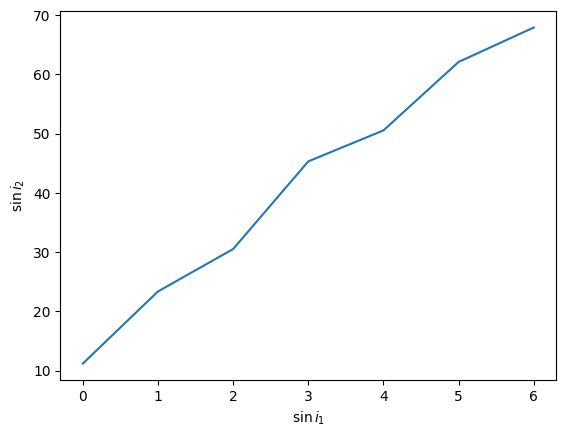

In [41]:
data = DATA ['Ingrid.txt']
deg2rad = np.pi / 180
xp, delta_xp, yp, delta_yp = tuple (zip (*data)) 
fig, ax = plt.subplots ()

ax.plot(xp)


ax.set_xlabel (r'$\sin i_1$')
ax.set_ylabel (r'$\sin i_2$')



La loi de Snell-Descartes énonce que

$$
n_1\sin(i_1) = n_2\sin(i_2)
$$

Soit $\sin(i_2) = \frac{n_1}{n_2}\sin(i_1)$ que l'on peut réprésenter sous la forme d'une équation de droite $y = ax+b$ où le coefficient directeur $a$ correspond à $\frac{n_1}{n_2}$ et l'ordonnée à l'origine qui est nulle.

L'objectif est donc de trouver le paramètre $a$ (et $b$) qui ajuste le mieux les observations.

4. Reprendre le script précédent et y ajouter l'ajustement linéaire des points expérimentaux avec la fonction ``np.polyfit (abscisses, ordonnées, ordre_du_polynôme)``
Tracer la droite ajustant au mieux les points expérimentaux en pointillés noirs.

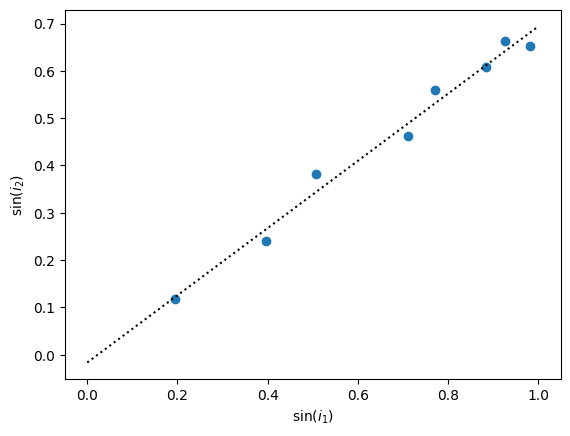

In [7]:
fig, ax = plt.subplots ()
ax.set_xlabel (r'$\sin (i_1)$')
ax.set_ylabel (r'$\sin (i_2)$')
nom_du_fichier = 'Ingrid.txt'






5. Quelle est la signification physique des paramètres $a$ et $b$ dans le cadre de la loi de Snell-Descartes ?

6. Modifier le script précédent pour afficher les données des deux fichiers et leur régression linéaire.

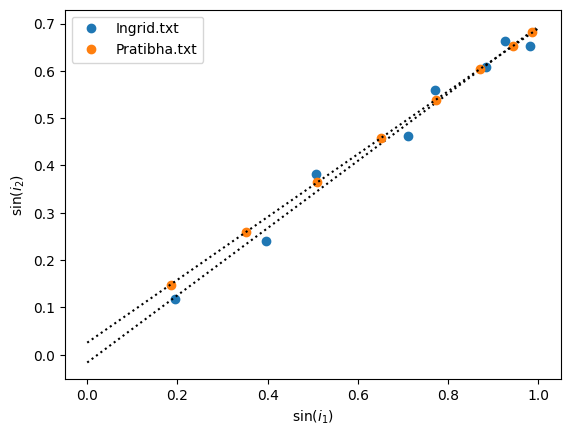

In [8]:
fig, ax = plt.subplots ()
ax.set_xlabel (r'$\sin (i_1)$')
ax.set_ylabel (r'$\sin (i_2)$')

for nom_du_fichier in filenames:





    

7. Ajouter à la légende les valeurs des coefficients $a$ et $b$

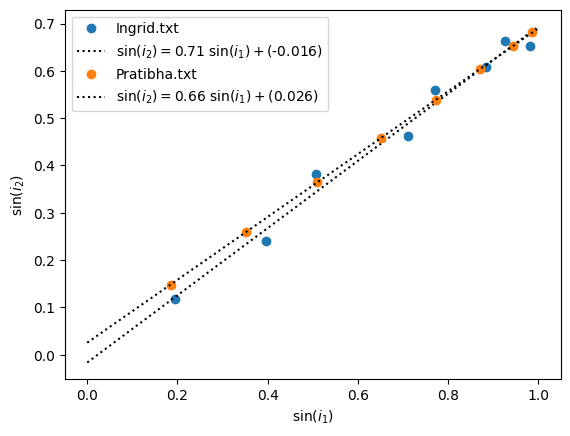

In [9]:
fig, ax = plt.subplots ()
ax.set_xlabel (r'$\sin (i_1)$')
ax.set_ylabel (r'$\sin (i_2)$')

for nom_du_fichier in filenames:






    
ax.legend ()

8. Compte tenu du fait que la réfraction a été mesurée sur un dioptre air-verre, discuter la conformité de ces deux résultats expérimentaux au modèle de la loi de Snell-Descartes.

# Ajustement polynomial

On considère la mesure d'un phénomène décrit par une loi de puissance 

$$
y = x^\alpha.
$$

Une série de mesures de $y$ en fonction de $x$ est réalisée dans le but de déterminer la valeur du paramètre $\alpha$.

1. En réutilisant les scripts de chargement de données du cours du chapitre 2, lire le contenu du fichier "power_law.txt".

In [10]:
# ouverture/lecture du fichier de données
nom_du_fichier = 'power_law.txt'
path2data = './data/'



print (f'Le fichier {nom_du_fichier} contient {N:d} lignes.\n')

Le fichier power_law.txt contient 504 lignes.



2. En réemployant à nouveau les procédures du chapitre 2, affecter aux variables _x_ et _y_ le contenu respectif des colonnes _abscisses_ et _ordonnées_.

3. Tracer les données expérimentales

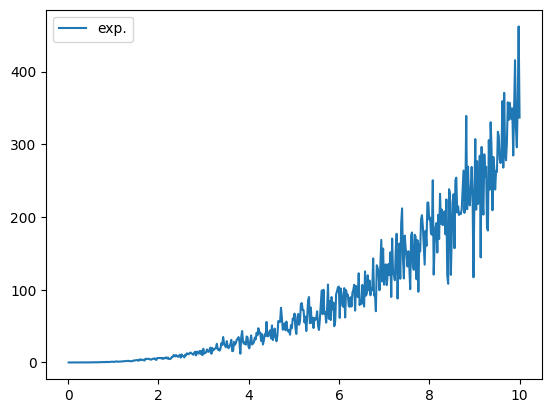

In [12]:
fig, ax = plt.subplots ()
# plot experimental data


ax.legend ()

4. Réaliser la régression polynomiale d'ordre $i = 2, 3$.
Déterminer les coefficients des polynômes $ P_3(x) = c_3 x^3 + c_2 x^2 + c_1 x + c_0$
et $P_2 (x) = d_2 x^2 + d_1 x + d_0$ qui ajustent au mieux le résultat de mesure.
Afficher les coefficients de ces polynômes et tracer leur courbes sur la figure.

In [ ]:
fig, ax = plt.subplots ()
# plot experimental data


# polynomial fit


    print (f'ordre {i} : ', p)
ax.legend ()
plt.show ()

![](power_law.png)
```
ordre 2 :  [  4.56060694 -15.39399659  13.94568121]
ordre 3 :  [ 0.38801705 -1.2654694   7.93364534 -5.5135894 ]
```

5. Pourquoi cette analyse ne permet-elle pas de conclure ?

6. Après avoir identifié le degré du polynôme définissant la fonction $\ln (y) = \ln (x^\alpha)$, rechercher ses coefficient avec la fonction ``np.polyfit()``.
Représenter graphiquement cette fonction et son ajustement calculé par ```np.polyval()```  .

In [ ]:
fig, ax = plt.subplots ()
# plot experimental data

# log fit



ax.legend ()
plt.show ()

7. Transformer la courbe d'ajustement précédemment obtenue pour l'afficher en fonction de $x$ et $y$ avec les autres courbes de la question 4.

In [ ]:
fig, ax = plt.subplots ()
# plot experimental data


# polynomial fit



    print (f'ordre {i} : ', p)

# log fit



print (f'log :     ', p)
ax.legend ()

8. Représenter conjointement la figure précédente en échelle linéaire et en échelle logarithmique
avec ```ax.set_xscale()``` et ```ax.set_yscale()```.

In [ ]:
# fit of the log
scales = ['linear', 'log']

fig, axes = plt.subplots (ncols = 2, figsize = (12.8, 4.8))
for j in range (2): 
    ax = axes [j]
    scale = scales [j]
    # plot experimental data
    
    # polynomial fit

    # log fit
    
    ax.legend ()
    ax.set_xscale (scale)
    ax.set_yscale (scale)

plt.show ()

_Remarque_ :
L'ajustement d'une loi de puissance requiert de faire varier $x$ sur au moins une décade.

Dans l'exemple ci-dessous où les 20 premiers et 399 derniers points ont été exclus, le paramètre $x$ ne varie plus que d'un facteur 5 et la discrimination entre les différents modèles n'est pas valable.

In [ ]:
# fit of the log
scales = ['linear', 'log']
xx, yy = x [20:100], y [20:100]
fig, axes = plt.subplots (ncols = 2, figsize = (12.8, 4.8))
for j in range (2): 
    ax = axes [j]
    scale = scales [j]
    # plot experimental data
    ax.plot (xx, yy, label = 'exp.')
    
    # polynomial fit
    for i in range (2, 4):
        p = np.polyfit (xx, yy, i)
        ax.plot (xx, np.polyval (p, xx), label = f'ordre {i}', linestyle = 'dashed')
        if j<1: # pour éviter la duplication de l'affichage
            print (f'ordre {i} : ', p)
            
    p = np.polyfit (np.log (xx), np.log (yy), 1)
    logy = np.polyval (p, np.log (xx))
    ax.plot(xx, np.exp (logy), label = 'log')
    ax.legend ()
    ax.set_xscale (scale)
    ax.set_yscale (scale)
print (f'log :     ', p)
plt.show ()

![](poor_range.png)